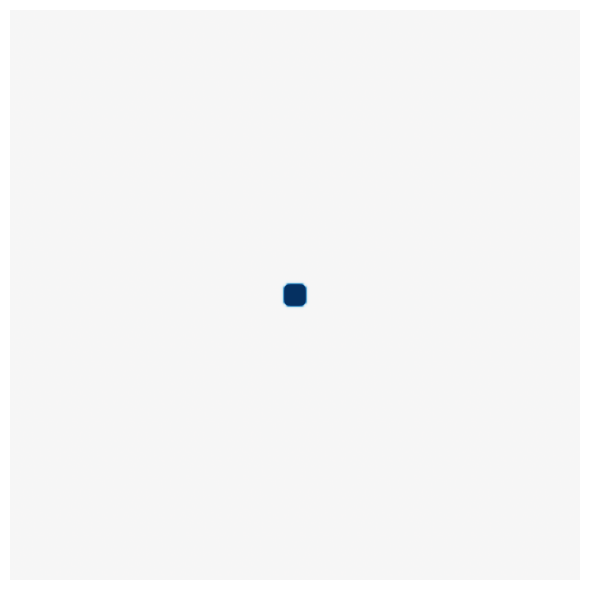

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# ---------------- Simulation parameters ----------------
N = 200          # grid size (NxN)
c = 1.0          # wave speed
dx = 1.0
dt = 0.4         # stability: dt <= dx / (c * sqrt(2))
frames = 350
interval_ms = 20

damping = 0.999  # small damping to avoid long-term numerical blow-up
c2 = (c * dt / dx) ** 2

# ---------------- State arrays ----------------
u = np.zeros((N, N), dtype=np.float64)       # current frame
u_prev = np.zeros((N, N), dtype=np.float64)  # previous frame
u_next = np.zeros((N, N), dtype=np.float64)  # next frame

# Smooth Gaussian pulse at the center for cleaner circular waves
x = np.arange(N)
y = np.arange(N)
X, Y = np.meshgrid(x, y, indexing='ij')
cx, cy = N // 2, N // 2
sigma = 5.0
u = 2.0 * np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma ** 2))
u_prev[:] = u

# ---------------- Plot setup ----------------
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(
    u,
    cmap='RdBu_r',
    vmin=-1.2,
    vmax=1.2,
    interpolation='bilinear',
    origin='lower',
    animated=True,
)
ax.set_title('2D Wave Equation Animation')
ax.axis('off')


def step(_frame):
    global u, u_prev, u_next

    # finite difference update on interior points
    u_next[1:-1, 1:-1] = (
        2.0 * u[1:-1, 1:-1]
        - u_prev[1:-1, 1:-1]
        + c2 * (
            u[2:, 1:-1]
            + u[:-2, 1:-1]
            + u[1:-1, 2:]
            + u[1:-1, :-2]
            - 4.0 * u[1:-1, 1:-1]
        )
    )

    u_next[1:-1, 1:-1] *= damping

    # hard-wall boundaries (Dirichlet u=0)
    u_next[0, :] = 0.0
    u_next[-1, :] = 0.0
    u_next[:, 0] = 0.0
    u_next[:, -1] = 0.0

    # Swap references (faster than copying whole arrays)
    u_prev, u, u_next = u, u_next, u_prev

    img.set_data(u)
    return (img,)


ani = animation.FuncAnimation(
    fig,
    step,
    frames=frames,
    interval=interval_ms,
    blit=True,
)

plt.close(fig)
HTML(ani.to_jshtml())